In [ ]:
!git clone https://github.com/mihaidusmanu/d2-net.git
%cd d2-net
!pip install torch torchvision h5py imageio imagesize scipy tqdm

Cloning into 'd2-net'...
remote: Enumerating objects: 223, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 223 (delta 51), reused 43 (delta 43), pack-reused 155 (from 1)
Receiving objects: 100% (223/223), 2.35 MiB | 21.71 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/d2-net


In [ ]:
!mkdir models !wget https://dusmanu.com/files/d2-net/d2_tf.pth -O models/d2_tf.pth

mkdir: invalid option -- 'O'
Try 'mkdir --help' for more information.


In [ ]:
!echo -e "box.png\nbox_in_scene.png" > image_list.txt

In [ ]:
!ls models/

ls: cannot access 'models/': No such file or directory


In [ ]:
!mkdir -p models
!wget https://dusmanu.com/files/d2-net/d2_tf.pth -O models/d2_tf.pth

--2026-08-28 03:55:57--  https://dusmanu.com/files/d2-net/d2_tf.pth
Resolving dusmanu.com (dusmanu.com)... 142.132.238.25
Connecting to dusmanu.com (dusmanu.com)|142.132.238.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30545768 (29M) [application/octet-stream]
Saving to: ‘models/d2_tf.pth’

models/d2_tf.pth    100%[===================>]  29.13M  18.7MB/s    in 1.6s    

2026-08-28 03:55:59 (18.7 MB/s) - ‘models/d2_tf.pth’ saved [30545768/30545768]



In [ ]:
!python extract_features.py --image_list_file image_list.txt --model_file models/d2_tf.pth

/content/d2-net/extract_features.py:13: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc
Namespace(image_list_file='image_list.txt', preprocessing='caffe', model_file='models/d2_tf.pth', max_edge=1600, max_sum_edges=2800, output_extension='.d2-net', output_type='npz', multiscale=False, use_relu=True)
  0% 0/2 [00:00<?, ?it/s]/content/d2-net/extract_features.py:87: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)
100% 2/2 [00:07<00:00,  3.97s/it]


In [ ]:
!ls -la models/

total 29840
drwxr-xr-x 2 root root     4096 Aug 28 03:55 .
drwxr-xr-x 9 root root     4096 Aug 28 03:56 ..
-rw-r--r-- 1 root root 30545768 Apr 11  2019 d2_tf.pth


In [ ]:
!du -h models/d2_tf.pth


30M	models/d2_tf.pth


In [ ]:
!head -c 200 models/d2_tf.pth

��
   little_endianq�X
   type_sizesq}q(X   shortqKX   intqKX   longqKuu.�}q (X	   epoch_idxqJ����X   modelqccollections
OrderedDict

In [ ]:
!python extract_features.py --image_list_file image_list.txt --model_file models/d2_tf.pth

/content/d2-net/extract_features.py:13: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc
Namespace(image_list_file='image_list.txt', preprocessing='caffe', model_file='models/d2_tf.pth', max_edge=1600, max_sum_edges=2800, output_extension='.d2-net', output_type='npz', multiscale=False, use_relu=True)
  0% 0/2 [00:00<?, ?it/s]/content/d2-net/extract_features.py:87: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)
100% 2/2 [00:09<00:00,  4.86s/it]


In [ ]:
!python match_d2net.py

python3: can't open file '/content/d2-net/match_d2net.py': [Errno 2] No such file or directory


D2-Net keypoints: 711 & 1457
D2-Net good matches: 143


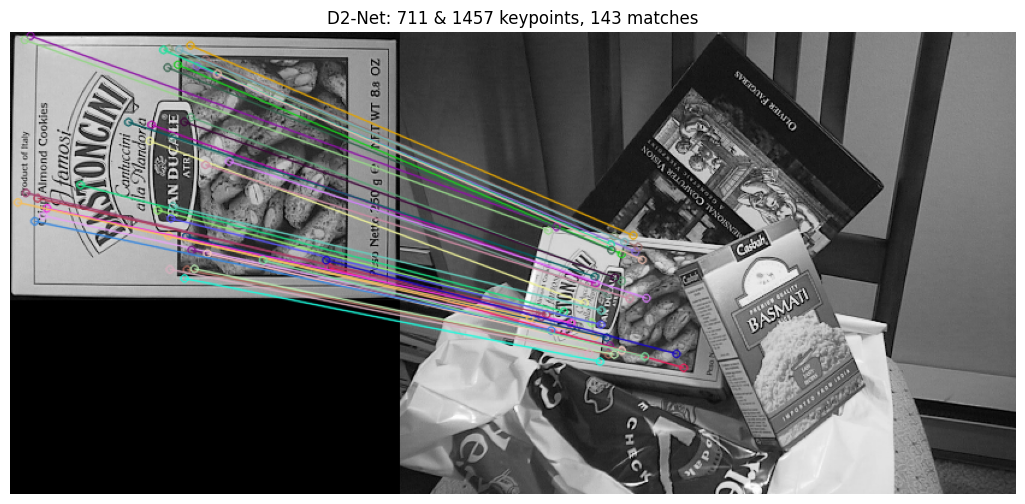

In [ ]:
"""
Run this AFTER extract_features.py has produced box.png.d2-net and
box_in_scene.png.d2-net (npz files containing keypoints/scores/descriptors).

This loads those two files, does nearest-neighbor matching, and draws the
matches -- same comparison format as your other algorithms.
"""

import numpy as np
import cv2
import matplotlib.pyplot as plt

feat1 = np.load("box.png.d2-net")
feat2 = np.load("box_in_scene.png.d2-net")

kp1_xy = feat1["keypoints"][:, :2]   # x, y (ignore scale column)
des1 = feat1["descriptors"]
kp2_xy = feat2["keypoints"][:, :2]
des2 = feat2["descriptors"]

print("D2-Net keypoints:", len(kp1_xy), "&", len(kp2_xy))

# D2-Net descriptors are float, L2-normalized -> use L2 BFMatcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1.astype(np.float32), des2.astype(np.float32))
matches = sorted(matches, key=lambda m: m.distance)
print("D2-Net good matches:", len(matches))

# Convert to cv2.KeyPoint for drawMatches
kp1 = [cv2.KeyPoint(x, y, 1) for x, y in kp1_xy]
kp2 = [cv2.KeyPoint(x, y, 1) for x, y in kp2_xy]

img1 = cv2.imread("box.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("box_in_scene.png", cv2.IMREAD_GRAYSCALE)

match_img = cv2.drawMatches(
    img1, kp1, img2, kp2, matches[:40], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(14, 6))
plt.imshow(match_img, cmap="gray")
plt.title(f"D2-Net: {len(kp1)} & {len(kp2)} keypoints, {len(matches)} matches")
plt.axis("off")
plt.savefig("matches_D2Net.png", bbox_inches="tight", dpi=120)
plt.show()